In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("dataset.csv")
df.head(3)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to order menu  9551 non-n

In [6]:
categorical_cols = ['Country Code', 'City', 'Locality', 'Cuisines', 'Currency', 'Price range']

for col in categorical_cols:
    if col in df.columns:
        print(f"Unique values in '{col}': {df[col].nunique()}")

Unique values in 'Country Code': 15
Unique values in 'City': 141
Unique values in 'Locality': 1208
Unique values in 'Cuisines': 1825
Unique values in 'Currency': 12
Unique values in 'Price range': 4


In [12]:
# 1. Drop missing rows, split the strings by comma, and expand them into a flat list
all_cuisines_series = df['Cuisines'].dropna().str.split(', ').explode()

# 2. Strip away any accidental trailing or leading whitespaces
all_cuisines_series = all_cuisines_series.str.strip()

# 3. Get the absolute unique list, sorted alphabetically
unique_cuisines_list = sorted(all_cuisines_series.unique())

# 4. Print Summary statistics
print(f"✨ Total Unique Cuisines in Dataset: {len(unique_cuisines_list)}\n")
print("📋 Full List of Unique Cuisines:")
print("--------------------------------")

# Print them out clearly row by row
for cuisine in unique_cuisines_list:
    print(f"- {cuisine}")

✨ Total Unique Cuisines in Dataset: 145

📋 Full List of Unique Cuisines:
--------------------------------
- Afghani
- African
- American
- Andhra
- Arabian
- Argentine
- Armenian
- Asian
- Asian Fusion
- Assamese
- Australian
- Awadhi
- BBQ
- Bakery
- Bar Food
- Belgian
- Bengali
- Beverages
- Bihari
- Biryani
- Brazilian
- Breakfast
- British
- Bubble Tea
- Burger
- Burmese
- B�_rek
- Cafe
- Cajun
- Canadian
- Cantonese
- Caribbean
- Charcoal Grill
- Chettinad
- Chinese
- Coffee and Tea
- Contemporary
- Continental
- Cuban
- Cuisine Varies
- Curry
- Deli
- Desserts
- Dim Sum
- Diner
- Drinks Only
- Durban
- D�_ner
- European
- Fast Food
- Filipino
- Finger Food
- Fish and Chips
- French
- Fusion
- German
- Goan
- Gourmet Fast Food
- Greek
- Grill
- Gujarati
- Hawaiian
- Healthy Food
- Hyderabadi
- Ice Cream
- Indian
- Indonesian
- International
- Iranian
- Irish
- Italian
- Izgara
- Japanese
- Juices
- Kashmiri
- Kebab
- Kerala
- Kiwi
- Korean
- Latin American
- Lebanese
- Lucknowi
- 

🔥 Top 20 Most Frequent Cuisines:
Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Street Food      562
American         390
Pizza            381
Mithai           380
Burger           251
Thai             234
Asian            233
Beverages        229
Ice Cream        226
Mexican          181
Name: count, dtype: int64


C:\Users\menes\AppData\Local\Temp\ipykernel_19796\1767502012.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cuisine_counts.head(20).values, y=cuisine_counts.head(20).index, palette="viridis")


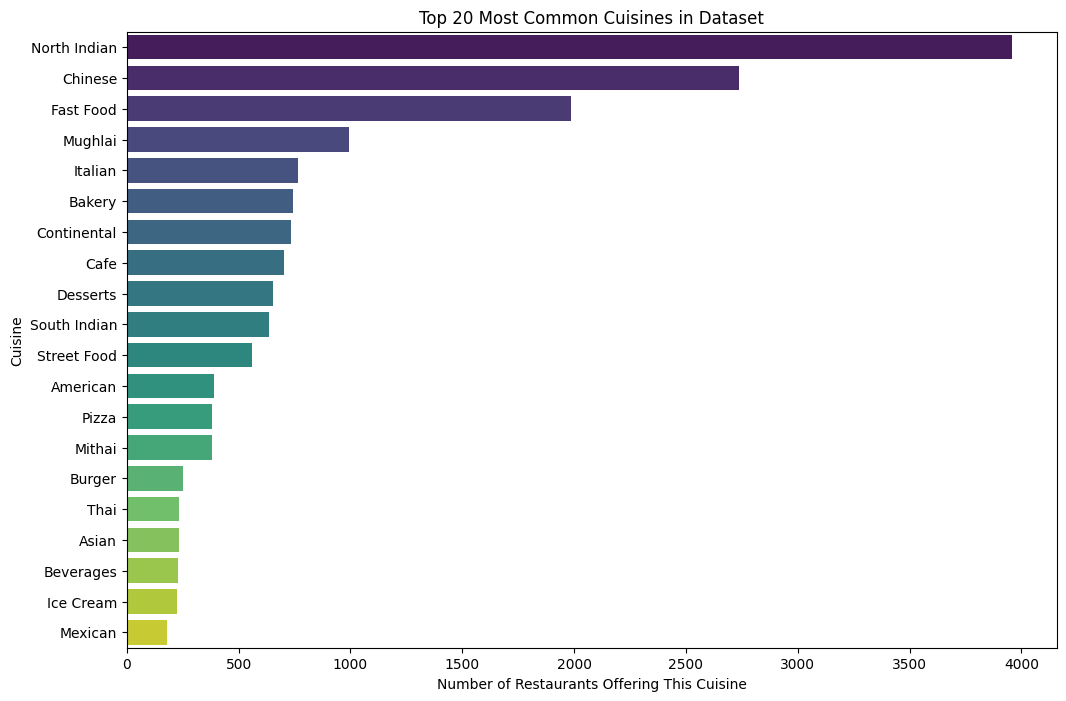

In [14]:
# Count occurrences of every clean, individual cuisine item
cuisine_counts = all_cuisines_series.value_counts()

# Print text breakdown of the top 20
print("🔥 Top 20 Most Frequent Cuisines:")
print(cuisine_counts.head(20))

# Create a clean horizontal bar chart for clarity
plt.figure(figsize=(12, 8))
sns.barplot(x=cuisine_counts.head(20).values, y=cuisine_counts.head(20).index, palette="viridis")
plt.title("Top 20 Most Common Cuisines in Dataset")
plt.xlabel("Number of Restaurants Offering This Cuisine")
plt.ylabel("Cuisine")
plt.show()

In [15]:

print(f"Total Unique Countries (Codes): {df['Country Code'].nunique()}")
print(f"Total Unique Cities:           {df['City'].nunique()}")
print(f"Total Unique Localities:       {df['Locality'].nunique()}")

# Let's see the top 15 cities represented in the dataset
print("\n🏙️ Top 15 Cities by Restaurant Count:")
city_counts = df['City'].value_counts()
print(city_counts.head(15))

Total Unique Countries (Codes): 15
Total Unique Cities:           141
Total Unique Localities:       1208

🏙️ Top 15 Cities by Restaurant Count:
City
New Delhi         5473
Gurgaon           1118
Noida             1080
Faridabad          251
Ghaziabad           25
Ahmedabad           21
Amritsar            21
Bhubaneshwar        21
Guwahati            21
Lucknow             21
Bras�_lia           20
Rio de Janeiro      20
S��o Paulo          20
Albany              20
Athens              20
Name: count, dtype: int64


In [16]:
unique_cities = sorted(df['City'].dropna().unique())

print(f"📋 Full List of All {len(unique_cities)} Cities:")
print("--------------------------------")
for city in unique_cities:
    print(f"- {city}")

📋 Full List of All 141 Cities:
--------------------------------
- Abu Dhabi
- Agra
- Ahmedabad
- Albany
- Allahabad
- Amritsar
- Ankara
- Armidale
- Athens
- Auckland
- Augusta
- Aurangabad
- Balingup
- Bandung
- Bangalore
- Beechworth
- Bhopal
- Bhubaneshwar
- Birmingham
- Bogor
- Boise
- Bras�_lia
- Cape Town
- Cedar Rapids/Iowa City
- Chandigarh
- Chatham-Kent
- Chennai
- Clatskanie
- Cochrane
- Coimbatore
- Colombo
- Columbus
- Consort
- Dalton
- Davenport
- Dehradun
- Des Moines
- Dicky Beach
- Doha
- Dubai
- Dubuque
- East Ballina
- Edinburgh
- Faridabad
- Fernley
- Flaxton
- Forrest
- Gainesville
- Ghaziabad
- Goa
- Gurgaon
- Guwahati
- Hepburn Springs
- Huskisson
- Hyderabad
- Indore
- Inner City
- Inverloch
- Jaipur
- Jakarta
- Johannesburg
- Kanpur
- Kochi
- Kolkata
- Lakes Entrance
- Lakeview
- Lincoln
- London
- Lorn
- Lucknow
- Ludhiana
- Macedon
- Macon
- Makati City
- Manchester
- Mandaluyong City
- Mangalore
- Mayfield
- Mc Millan
- Middleton Beach
- Miller
- Mohali
- M